# Explainability (SVM Coefficients, SHAP, and LIME)

We use the trained LinearSVC model to explain its own predictions three ways: the raw coefficients it learned (most model-faithful), a SHAP summary of global feature importance per class, and a LIME breakdown of one individual prediction.

In [1]:
import os
while not os.path.isdir("src"):
    os.chdir("..")
print("Working directory set to repo root:", os.getcwd())

Working directory set to repo root: d:\TherapyLM-Design-Project


In [7]:
import sys
sys.path.append("src")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from explainability import load_artifacts, svm_top_words

artifacts = load_artifacts(models_dir="models")
test_df = pd.read_csv("data/processed/test.csv").dropna(subset=["statement"])
texts = test_df["statement"].astype(str)

## 1. SVM coefficients — top words per class

We pulled the top-weighted words per class directly from the trained LinearSVC coefficients — the most model-faithful explanation available, since these are the literal features driving each decision. We found, for example, that Suicidal is driven by explicit crisis words ("suicidal", "suicide", "kms", "overdose"), while Personality disorder is dominated almost entirely by "avpd"/"avoidant" — reflecting that this class in our data skews heavily toward one specific condition rather than personality disorders broadly.

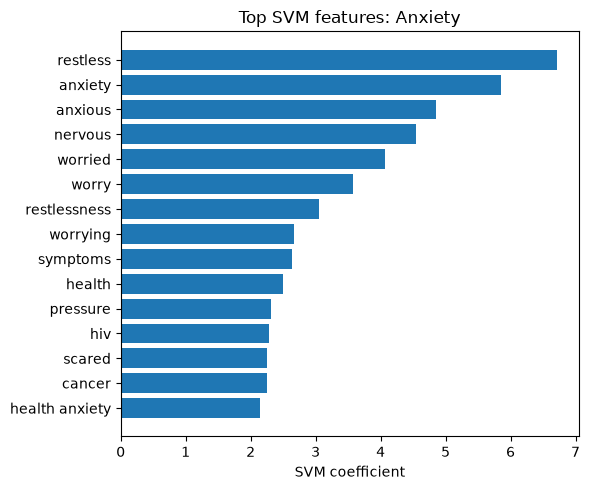

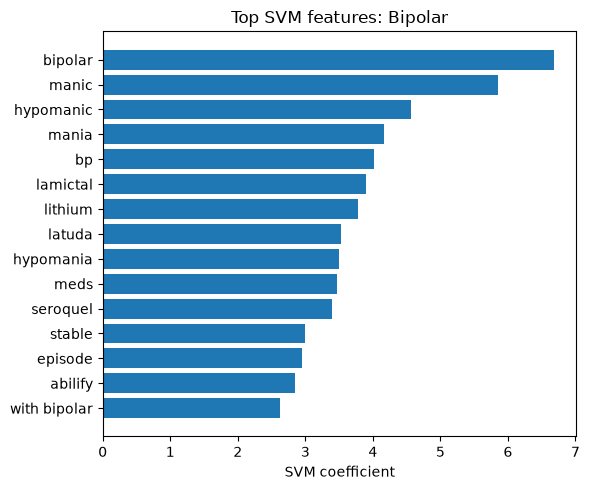

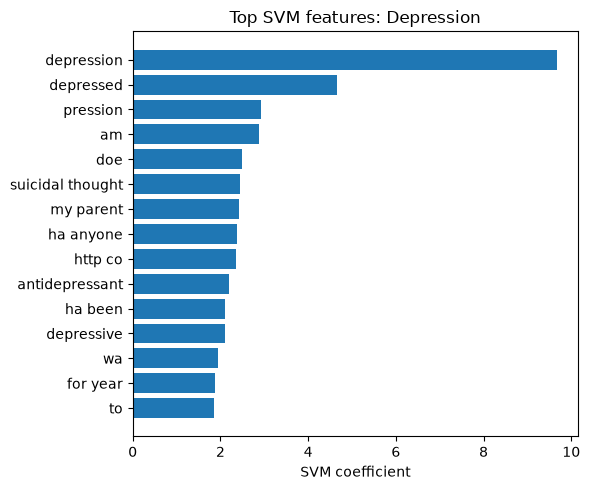

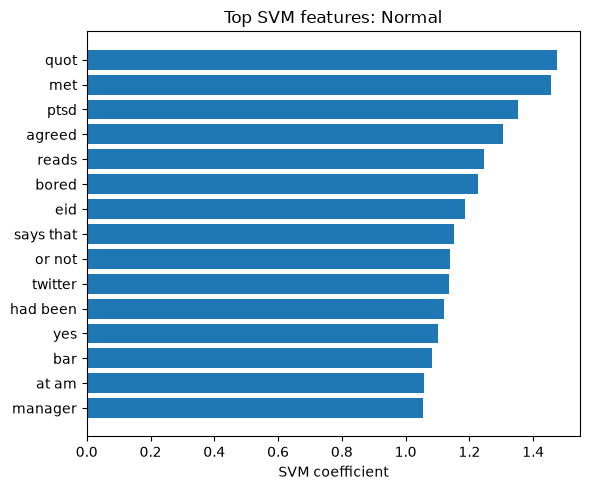

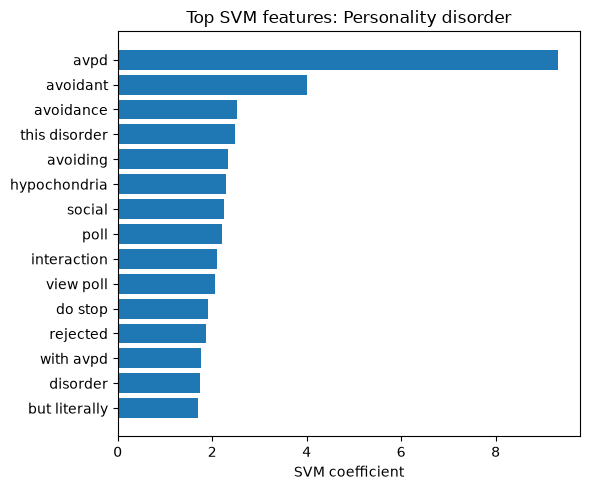

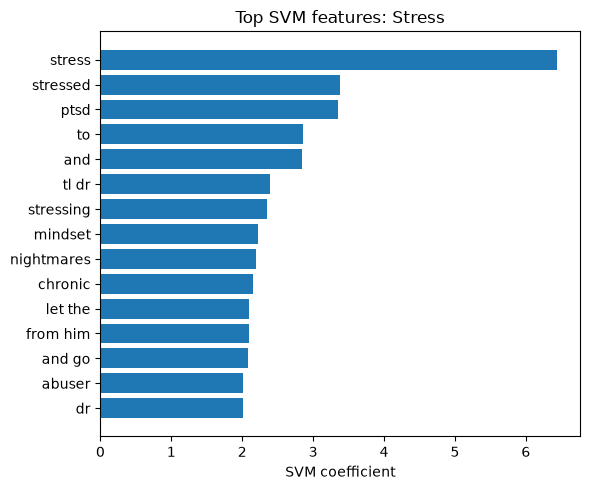

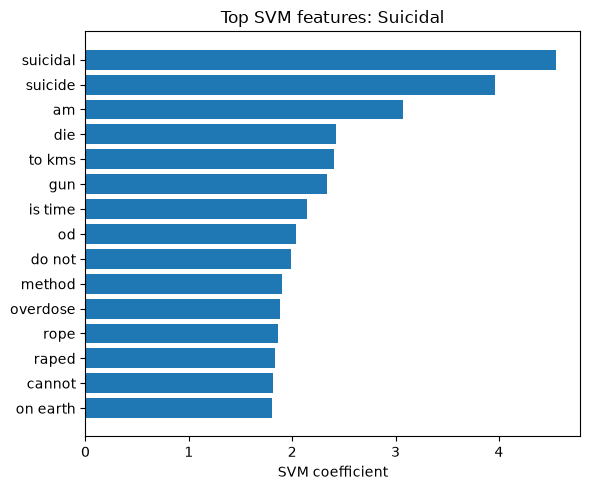

Saved per-class SVM word charts to results/figures/


{'Anxiety': 'results/figures/svm_top_words_Anxiety.png',
 'Bipolar': 'results/figures/svm_top_words_Bipolar.png',
 'Depression': 'results/figures/svm_top_words_Depression.png',
 'Normal': 'results/figures/svm_top_words_Normal.png',
 'Personality disorder': 'results/figures/svm_top_words_Personality_disorder.png',
 'Stress': 'results/figures/svm_top_words_Stress.png',
 'Suicidal': 'results/figures/svm_top_words_Suicidal.png'}

In [8]:
svm_top_words(
    artifacts["vectorizer"], artifacts["svm"],
    out_dir="results/figures", show=True,
)

## 2. SHAP summary — global feature importance

We use SHAP's `LinearExplainer`, which is built specifically for linear models like our LinearSVC — no XGBoost dependency needed here at all. This gives us a per-class summary of which features push predictions toward or away from that class across many examples at once, complementing the raw-coefficient view above with a distributional one.

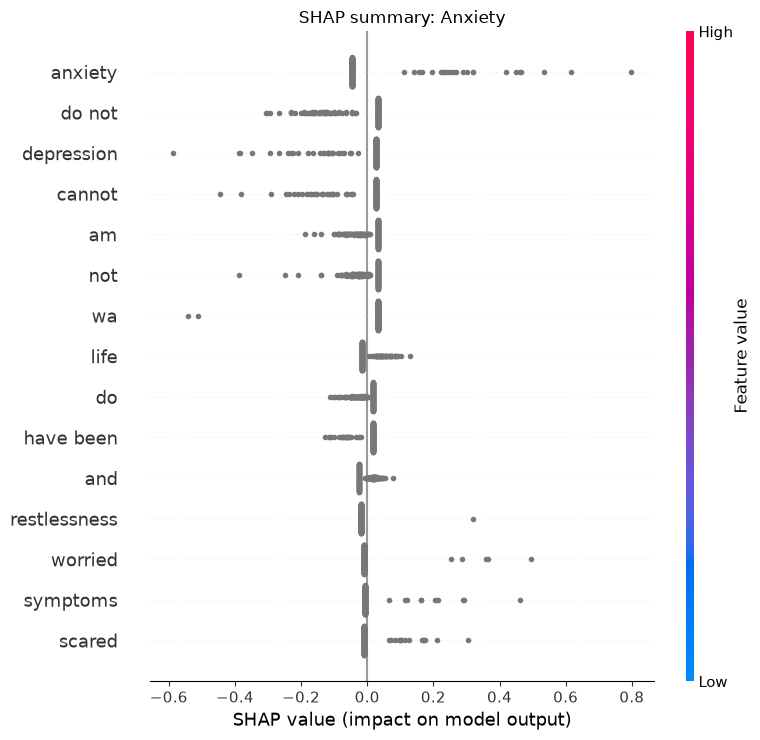

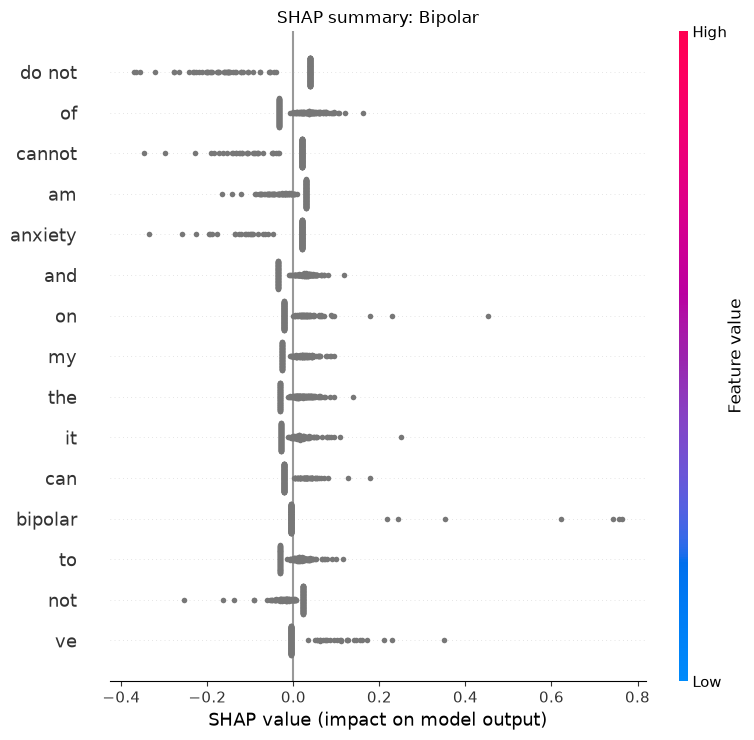

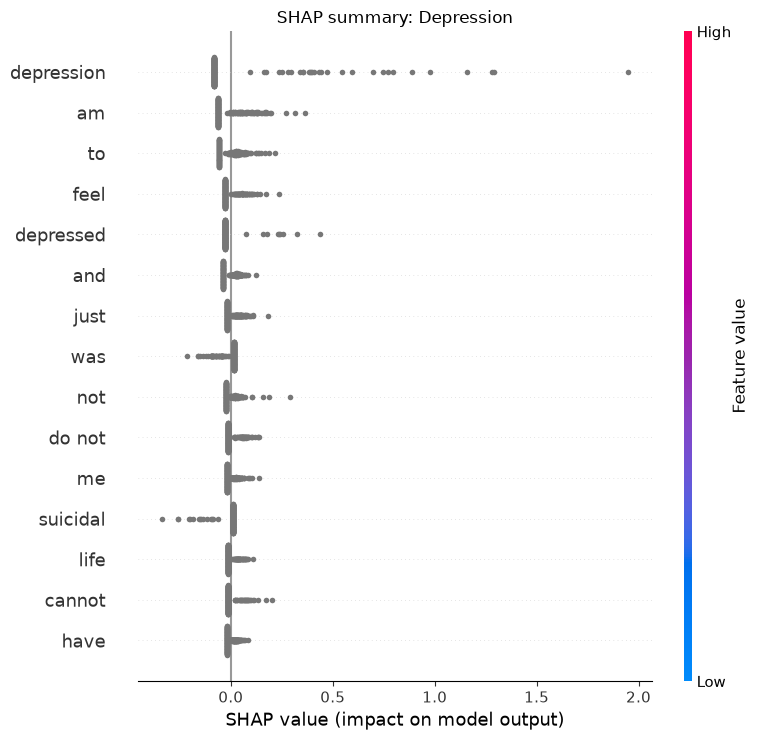

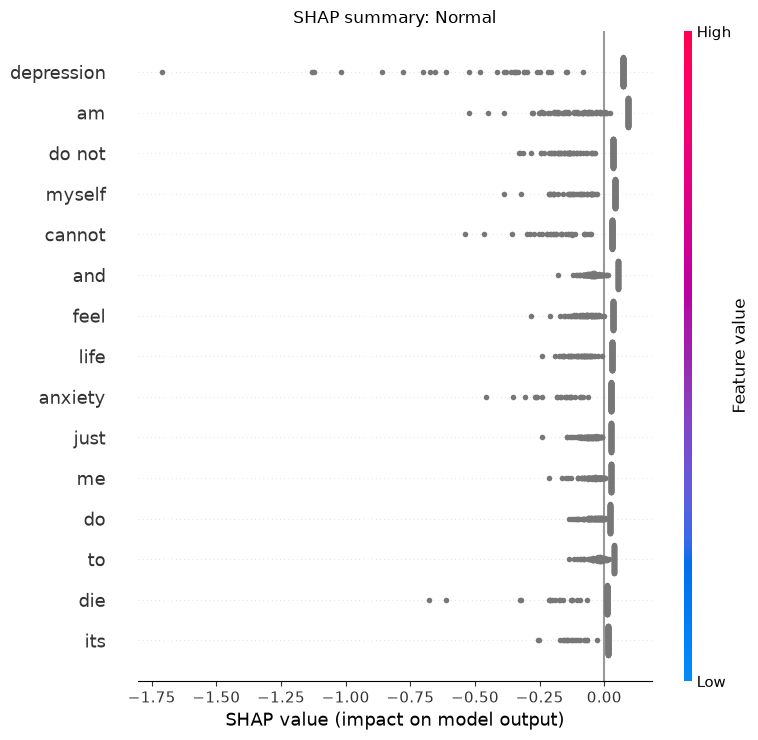

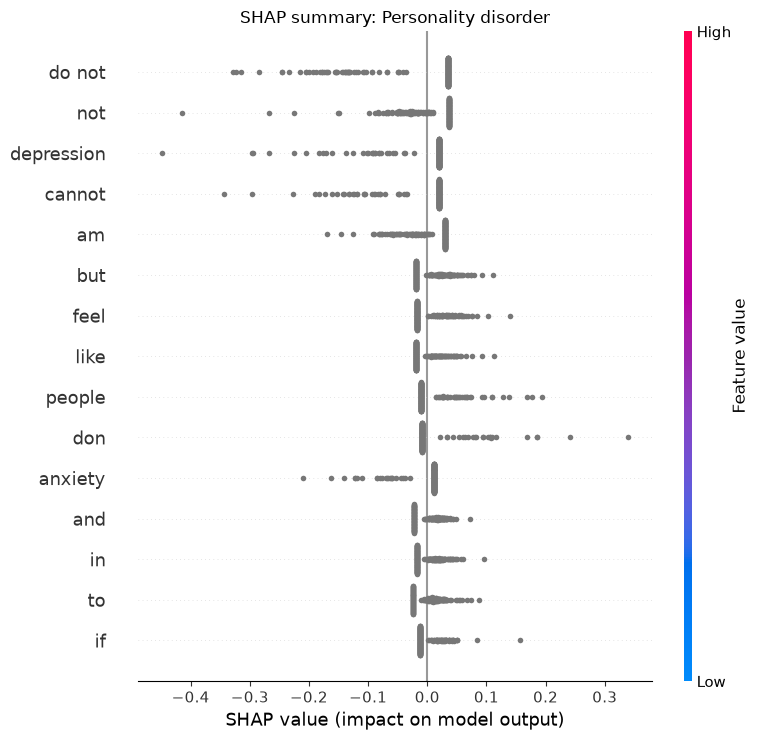

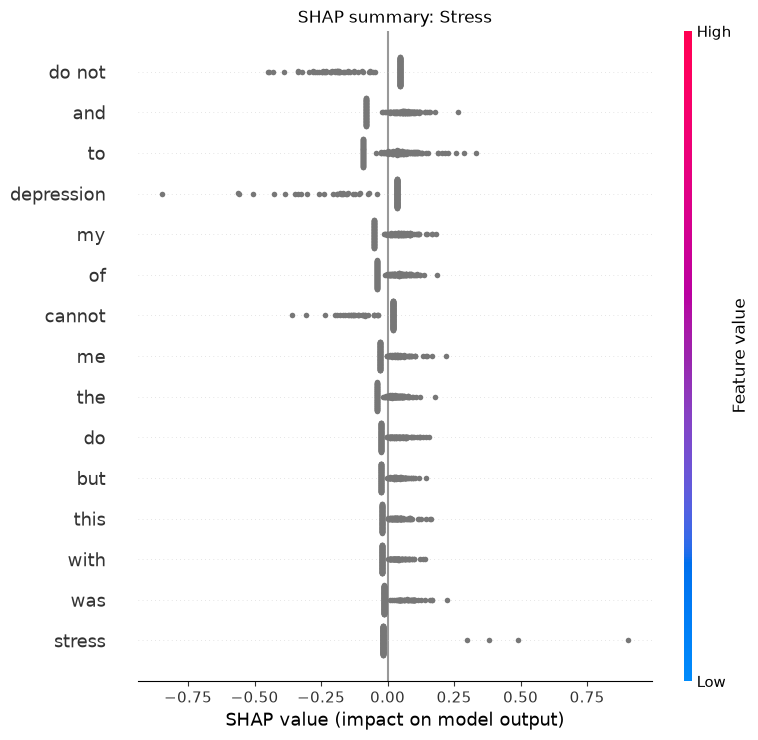

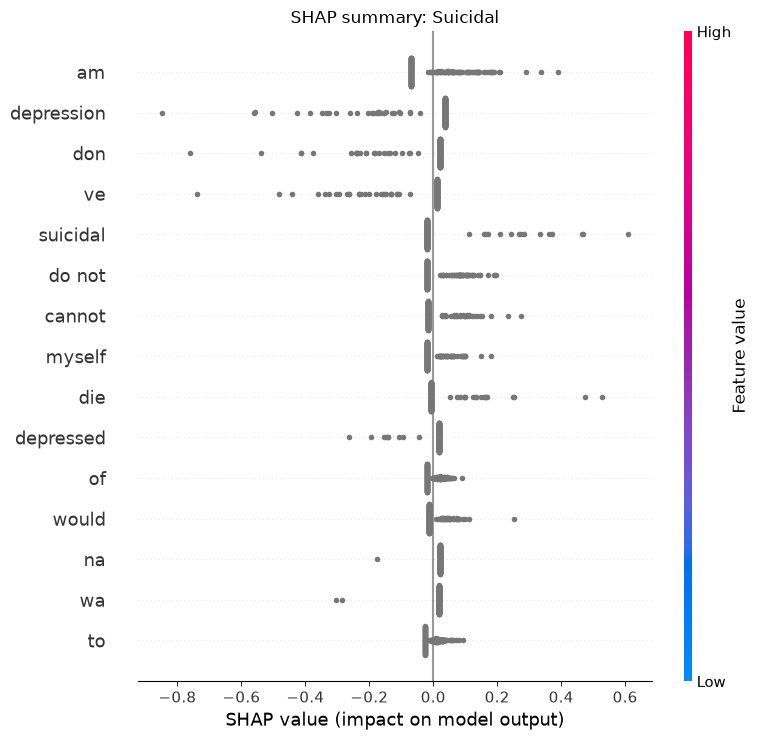

In [9]:
import shap

sample_texts = texts.sample(n=100, random_state=42)
X_sample = artifacts["vectorizer"].transform(sample_texts)
explainer = shap.LinearExplainer(artifacts["svm"], X_sample)

X_explain_texts = texts.iloc[:200]
X_explain = artifacts["vectorizer"].transform(X_explain_texts)
shap_values = explainer.shap_values(X_explain)
feature_names = artifacts["vectorizer"].get_feature_names_out()

os.makedirs("results/figures", exist_ok=True)
for i, cls in enumerate(artifacts["label_encoder"].classes_):
    plt.figure()
    shap.summary_plot(shap_values[:, :, i], X_explain, feature_names=feature_names,
                       show=False, max_display=15)
    plt.title(f"SHAP summary: {cls}")
    plt.tight_layout()
    safe = cls.replace(" ", "_")
    plt.savefig(f"results/figures/shap_summary_{safe}.png", dpi=120)
    plt.show()

## 3. LIME — one local example

LinearSVC doesn't expose `predict_proba` the way most classifiers do (only `decision_function`), so we convert its per-class scores to pseudo-probabilities via softmax. This is a standard, well-established way to make a margin-based classifier work with any tool expecting probability outputs, LIME included. We picked one post to explain locally; change `index` below to look at a different one (e.g. a misclassified post is often the most interesting to show).

In [10]:
import numpy as np
from lime.lime_text import LimeTextExplainer

def svm_predict_proba(texts_list):
    X = artifacts["vectorizer"].transform(texts_list)
    scores = artifacts["svm"].decision_function(X)
    exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)

class_names = list(artifacts["label_encoder"].classes_)
explainer = LimeTextExplainer(class_names=class_names)

index = 0
text_instance = texts.iloc[index]
print("Explaining post:", text_instance[:200])

exp = explainer.explain_instance(text_instance, svm_predict_proba, num_features=10, top_labels=1)
exp.save_to_file("results/figures/lime_example_svm.html")

# exp.show_in_notebook() uses an IPython import path that's broken on some
# newer IPython versions -- display it via the current IPython API directly
# instead, with a plain-text fallback so this can't silently fail either.
try:
    from IPython.display import display, HTML
    display(HTML(exp.as_html()))
except Exception as e:
    print(f"(inline HTML display unavailable: {e} -- see results/figures/lime_example_svm.html instead)")

top_label = exp.available_labels()[0]
print(f"\nTop predicted class: {class_names[top_label]}")
print("Contributing words (word, weight):")
for word, weight in exp.as_list(label=top_label):
    print(f"  {word:20s} {weight:+.4f}")

Explaining post: today i felt like doing something about this so i decided to make an account and come here ive been suicidal for like a year now and i cant fucking bear it ive almost killed myself quite alot but appa



Top predicted class: Depression
Contributing words (word, weight):
  depression           +0.1918
  suicidal             -0.0920
  year                 +0.0466
  here                 -0.0439
  cant                 -0.0393
  might                -0.0319
  of                   -0.0309
  apparently           -0.0291
  shit                 +0.0174
  together             +0.0157


## Final results tables for the presentation

**Table 1 — Full test set (classical ML only)**
From `results/tables/full_test_metrics.csv` — SVM/RF/XGBoost on the full ~10,461-row held-out test set.

**Table 2 — Everything, shared 500-post subset**
From `results/tables/multi_llm_metrics_summary.csv` — classical ML re-evaluated on the exact same 500 posts as every LLM across all 3 families, so every model, any family, is on one shared table. This is the headline comparison our presentation is built around.

**Per-class breakdown**, useful for a "which classes are hardest" slide: `results/tables/full_test_per_class_metrics.csv` (classical ML) and `results/tables/multi_llm_metrics_per_class.csv` (all LLMs + classical ML on the shared subset).

## Done
Figures are in `results/figures/`.